# The Merton Model: Reading Default Risk from Stock Prices

**Question:** A firm's asset value and asset volatility can't be observed, but its stock price can. If equity is a call option on the firm's assets, can we invert the option formula to recover the assets and estimate how close the firm is to default?

This notebook:
1. Prices equity as a call and debt as risk-free debt minus a put (Merton, 1974).
2. Implements three estimators: the **two-equation** solve, the **iterative KMV** procedure (Vassalou & Xing, 2004), and the **naive DD** of Bharath & Shumway (2008).
3. Checks them on **simulated firms** where the true answer is known.
4. Applies them to eight listed companies with very different leverage, both as a cross-section and as a 2023-2026 time series.
5. Maps the non-linear link between leverage, volatility and default probability, and lists where the model breaks.

*Inspired by WQU MScFE 560, Module 1 (credit risk), Module 4 L3 (home equity as an option), Module 5 L3 (probability of default and credit spreads), and Module 6 L1 (balance sheet: leverage and default).*

## 1. Equity is a call option on the firm

A firm has assets $V$ and zero-coupon debt with face value $F$ due at $T$. At maturity, shareholders either repay $F$ and keep $V-F$, or, with limited liability, hand the firm to creditors. So

$$ E_T = \max(V_T - F,\,0), \qquad D_T = \min(V_T, F) = F - \max(F - V_T, 0). $$

Equity is a **call** on the assets. Debt is **risk-free debt minus a put**. This is the same payoff as home equity with a non-recourse mortgage (Module 4). If $V$ follows geometric Brownian motion with volatility $\sigma_V$, Black-Scholes gives

$$ E = V N(d_1) - F e^{-rT} N(d_2), \quad d_{1} = \frac{\ln(V/F) + (r + \tfrac12\sigma_V^2)T}{\sigma_V\sqrt T},\; d_2 = d_1 - \sigma_V\sqrt T, $$

and Itô's lemma links equity and asset volatility:

$$ \sigma_E E = N(d_1)\,\sigma_V V. $$

**Distance to default** is the number of standard deviations between the expected asset value and the default point. The probability of default is $\mathrm{PD} = N(-\mathrm{DD})$:

$$ \mathrm{DD} = \frac{\ln(V/F) + (\mu - \tfrac12\sigma_V^2)T}{\sigma_V\sqrt T}. $$

With $\mu = r$ this gives the risk-neutral PD $N(-d_2)$, which is the one that prices the debt. The model credit spread is $s = -\tfrac1T\ln\!\big(D/F\big) - r$, where $D = V - E$.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import fsolve

plt.rcParams.update({"figure.figsize": (10, 4.5), "axes.grid": True, "grid.alpha": 0.3})
RNG = np.random.default_rng(1974)
DAYS = 252

E = 33.23   D = 66.77   σ_E = 72.0%
DD (risk-neutral) = 1.46   PD = 7.19%   spread = 73 bps


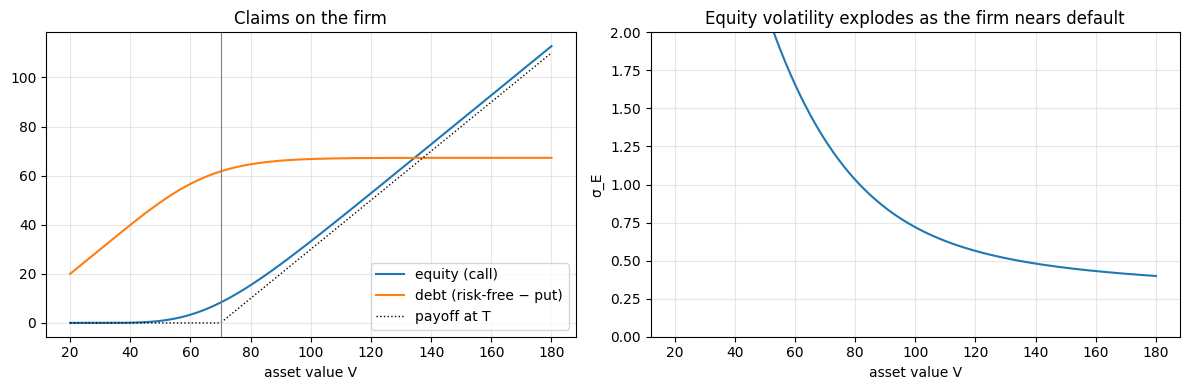

In [2]:
def d1d2(V, F, r, sig, T=1.0):
    d1 = (np.log(V / F) + (r + 0.5 * sig ** 2) * T) / (sig * np.sqrt(T))
    return d1, d1 - sig * np.sqrt(T)


def equity_value(V, F, r, sig, T=1.0):
    d1, d2 = d1d2(V, F, r, sig, T)
    return V * norm.cdf(d1) - F * np.exp(-r * T) * norm.cdf(d2)


def distance_to_default(V, F, sig, mu, T=1.0):
    return (np.log(V / F) + (mu - 0.5 * sig ** 2) * T) / (sig * np.sqrt(T))


def credit_spread(V, E, F, r, T=1.0):
    D = V - E
    return -np.log(D / F) / T - r


# Illustration: V = 100, F = 70, r = 4%, σ_V = 25%
V0, F0, r0, s0 = 100.0, 70.0, 0.04, 0.25
E0 = equity_value(V0, F0, r0, s0)
d1, _ = d1d2(V0, F0, r0, s0)
print(f"E = {E0:.2f}   D = {V0 - E0:.2f}   σ_E = {norm.cdf(d1) * s0 * V0 / E0:.1%}")
print(f"DD (risk-neutral) = {distance_to_default(V0, F0, s0, r0):.2f}   PD = {norm.cdf(-distance_to_default(V0, F0, s0, r0)):.2%}"
      f"   spread = {credit_spread(V0, E0, F0, r0) * 1e4:.0f} bps")

Vs = np.linspace(20, 180, 200)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(Vs, equity_value(Vs, F0, r0, s0), label="equity (call)")
axes[0].plot(Vs, Vs - equity_value(Vs, F0, r0, s0), label="debt (risk-free − put)")
axes[0].plot(Vs, np.maximum(Vs - F0, 0), "k:", lw=1, label="payoff at T")
axes[0].axvline(F0, color="grey", lw=0.8); axes[0].set_xlabel("asset value V"); axes[0].legend(); axes[0].set_title("Claims on the firm")
axes[1].plot(Vs, norm.cdf(d1d2(Vs, F0, r0, s0)[0]) * s0 * Vs / equity_value(Vs, F0, r0, s0))
axes[1].set_xlabel("asset value V"); axes[1].set_ylabel("σ_E"); axes[1].set_title("Equity volatility explodes as the firm nears default")
axes[1].set_ylim(0, 2)
plt.tight_layout(); plt.show()

The right panel is why a single "equity volatility" number is misleading. Equity volatility depends on leverage, so it changes whenever the asset value moves.

## 2. Three estimators

We observe the daily market value of equity $E_t$, the default point $F$ and the rate $r$. We need $V$ and $\sigma_V$.

| Method | Idea | Weakness |
|---|---|---|
| **Two-equation** (Jones et al., 1984) | Solve the pricing and volatility equations jointly for $(V, \sigma_V)$ using today's $E$ and a historical $\sigma_E$ | Treats $\sigma_E$ as constant even though leverage moves |
| **Iterative KMV** (Vassalou & Xing, 2004) | Guess $\sigma_V$ → invert the call price for each day's $V_t$ → re-estimate $\sigma_V$ from $\ln V_t$ returns → repeat until it converges | Needs a full year of daily data |
| **Naive** (Bharath & Shumway, 2008) | $\sigma_D = 0.05 + 0.25\sigma_E$, $\sigma_V = \frac{E}{E+F}\sigma_E + \frac{F}{E+F}\sigma_D$, $V = E+F$, drift = past stock return | Not a real inversion, but forecasts default about as well |

The KMV default point is **short-term debt + ½ long-term debt**, with a one-year horizon.

In [3]:
def invert_assets(E, F, r, sig, T=1.0, tol=1e-10, max_iter=100):
    # Solve equity_value(V) = E for V, vectorized Newton from the right (monotone convergence: call is convex)
    E, F, r = np.broadcast_arrays(np.asarray(E, float), np.asarray(F, float), np.asarray(r, float))
    V = E + F
    for _ in range(max_iter):
        d1, _ = d1d2(V, F, r, sig, T)
        step = (equity_value(V, F, r, sig, T) - E) / np.maximum(norm.cdf(d1), 1e-12)
        V = np.maximum(V - step, E)
        if np.max(np.abs(step) / V) < tol:
            break
    return V


def two_equation(E, sig_E, F, r, T=1.0):
    def eqs(x):
        V, s = x
        d1, _ = d1d2(V, F, r, s, T)
        return [equity_value(V, F, r, s, T) - E, norm.cdf(d1) * s * V - sig_E * E]
    V, s = fsolve(eqs, [E + F, sig_E * E / (E + F)])
    return V, s


def kmv_iterative(E, F, r, T=1.0, tol=1e-4, max_iter=200):
    # E, F, r: arrays of daily values over the estimation window (F may be constant)
    E = np.asarray(E, float)
    sig_E = np.std(np.diff(np.log(E)), ddof=1) * np.sqrt(DAYS)
    F_last = np.atleast_1d(F)[-1]
    sig = sig_E * E[-1] / (E[-1] + F_last)
    for it in range(max_iter):
        V = invert_assets(E, F, r, sig, T)
        lr = np.diff(np.log(V))
        sig_new = np.std(lr, ddof=1) * np.sqrt(DAYS)
        if abs(sig_new - sig) < tol:
            sig = sig_new
            break
        sig = sig_new
    mu = lr.mean() * DAYS + 0.5 * sig ** 2
    return {"V": V[-1], "sigma_V": sig, "mu": mu, "sigma_E": sig_E, "iters": it + 1}


def naive_dd(E, F, sig_E, past_ret, T=1.0):
    sig_D = 0.05 + 0.25 * sig_E
    sig_V = E / (E + F) * sig_E + F / (E + F) * sig_D
    return (np.log((E + F) / F) + (past_ret - 0.5 * sig_V ** 2) * T) / (sig_V * np.sqrt(T)), sig_V

## 3. Validation on simulated firms

Before trusting real-data estimates we test the estimators on firms where we *know* the answer. Each firm's assets follow GBM with a random $\sigma_V \in [10\%, 50\%]$ and a random leverage $F/V_0 \in [0.3, 0.9]$. The market prices equity with the true model every day, and each estimator sees only the equity series. Keep in mind that $\sigma_V$ estimated from one year of daily data has sampling noise of about $\sigma_V/\sqrt{2\cdot 252} \approx 4.5\%$ of its value, even with a perfect method.

In [4]:
def simulate_firm(sig_V, lev, mu=0.06, r=0.04, n=DAYS + 1, rng=RNG):
    V0, F = 100.0, 100.0 * lev
    z = rng.standard_normal(n - 1)
    V = V0 * np.exp(np.concatenate([[0], np.cumsum((mu - 0.5 * sig_V ** 2) / DAYS + sig_V / np.sqrt(DAYS) * z)]))
    return V, equity_value(V, F, r, sig_V), F, r


rows = []
for _ in range(300):
    sV, lev = RNG.uniform(0.10, 0.50), RNG.uniform(0.3, 0.9)
    V, E, F, r = simulate_firm(sV, lev)
    true_dd = distance_to_default(V[-1], F, sV, r)
    k = kmv_iterative(E, F, r)
    V2, s2 = two_equation(E[-1], k["sigma_E"], F, r)
    ndd, sN = naive_dd(E[-1], F, k["sigma_E"], r)
    rows.append({"true_sigV": sV, "lev": F / V[-1], "true_DD": true_dd,
                 "KMV_sigV": k["sigma_V"], "TwoEq_sigV": s2, "Naive_sigV": sN,
                 "KMV_DD": distance_to_default(k["V"], F, k["sigma_V"], r),
                 "TwoEq_DD": distance_to_default(V2, F, s2, r), "Naive_DD": ndd})
sim = pd.DataFrame(rows)

err = pd.DataFrame({m: {"σ_V median abs % error": ((sim[f"{m}_sigV"] / sim.true_sigV - 1).abs().median()),
                        "σ_V median % bias": (sim[f"{m}_sigV"] / sim.true_sigV - 1).median(),
                        "DD median abs error": (sim[f"{m}_DD"] - sim.true_DD).abs().median(),
                        "DD rank corr with truth": sim[f"{m}_DD"].corr(sim.true_DD, method="spearman")}
                    for m in ["KMV", "TwoEq", "Naive"]}).T
err.style.format({"σ_V median abs % error": "{:.1%}", "σ_V median % bias": "{:+.1%}",
                  "DD median abs error": "{:.2f}", "DD rank corr with truth": "{:.3f}"})

,σ_V median abs % error,σ_V median % bias,DD median abs error,DD rank corr with truth
KMV,4.2%,+0.5%,0.09,0.997
TwoEq,13.6%,+1.2%,0.29,0.964
Naive,34.3%,+34.3%,0.60,0.969


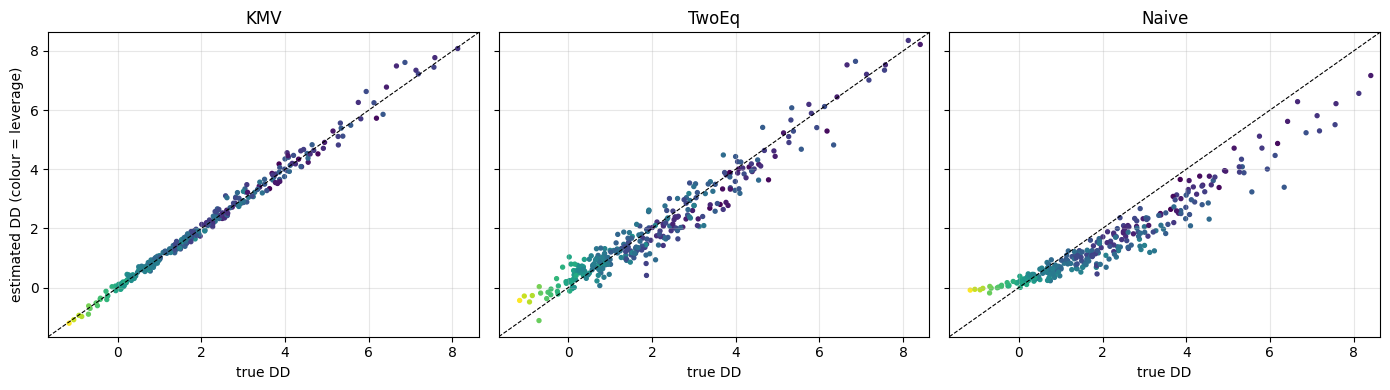

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True, sharey=True)
lim = [sim.true_DD.min() - 0.5, np.percentile(sim.true_DD, 98) + 0.5]
for ax, m in zip(axes, ["KMV", "TwoEq", "Naive"]):
    ax.scatter(sim.true_DD, sim[f"{m}_DD"], s=8, c=sim.lev, cmap="viridis")
    ax.plot(lim, lim, "k--", lw=0.8); ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_title(m); ax.set_xlabel("true DD")
axes[0].set_ylabel("estimated DD (colour = leverage)")
plt.tight_layout(); plt.show()

## 4. Real firms: data

Eight US firms ranging from AAA-like balance sheets to heavily indebted cyclicals:

- **Low leverage:** AAPL, MSFT, KO
- **High debt, stable:** T (telecom)
- **Cyclical / stressed:** F (autos, including its captive finance arm), INTC, AAL (airline), CCL (cruise line)

Inputs from yfinance: daily close × shares outstanding = market value of equity. The default point is **Current Debt + ½ Long Term Debt** from the annual balance sheet, treated as available 90 days after the fiscal year-end (point-in-time, no look-ahead). The risk-free rate is the 13-week T-bill (^IRX). If yfinance is unavailable, synthetic firms are generated so the notebook still runs.

In [6]:
TICKERS = ["AAPL", "MSFT", "KO", "T", "F", "INTC", "AAL", "CCL"]
REPORT_LAG = pd.Timedelta(days=90)


def load_firm(t):
    import yfinance as yf
    tk = yf.Ticker(t)
    bs = tk.balance_sheet
    if bs is None or bs.empty:
        raise ValueError(f"no balance sheet for {t}")
    get = lambda row: bs.loc[row] if row in bs.index else pd.Series(0.0, index=bs.columns)
    F = (get("Current Debt").fillna(0) + 0.5 * get("Long Term Debt").fillna(0)) / 1e9
    shares = get("Ordinary Shares Number") / 1e9
    fund = pd.DataFrame({"F": F, "shares": shares}).dropna()
    fund.index = pd.to_datetime(fund.index) + REPORT_LAG
    px = yf.download(t, start=str((fund.index.min() - pd.Timedelta(days=400)).date()),
                     progress=False, auto_adjust=False)["Close"].squeeze().dropna()
    if len(px) < 2 * DAYS:
        raise ValueError(f"too little price data for {t}")
    fund = fund.sort_index().reindex(px.index, method="ffill")
    pit = fund["F"].notna()  # True once a published balance sheet exists
    # before the first report, back-fill the earliest one; such windows are flagged and skipped in the history
    fund = fund.bfill()
    return pd.DataFrame({"E": px * fund["shares"], "F": fund["F"], "price": px, "pit": pit})


def synthetic_universe():
    idx = pd.bdate_range("2021-01-01", "2026-09-01")
    out = {}
    for i, t in enumerate(TICKERS):
        sV, lev = 0.15 + 0.04 * i, 0.05 + 0.1 * i
        V, E, F, _ = simulate_firm(sV, lev, n=len(idx))
        out[t] = pd.DataFrame({"E": E, "F": F, "price": E, "pit": True}, index=idx)
    return out, pd.Series(0.04, index=idx)


try:
    import yfinance as yf
    firms = {t: load_firm(t) for t in TICKERS}
    irx = yf.download("^IRX", start="2020-01-01", progress=False)["Close"].squeeze().dropna()
    if len(irx) < DAYS:
        raise ValueError("no T-bill data")
    rf = np.log1p(irx / 100)
    SOURCE = "yfinance"
except Exception as exc:
    print(f"yfinance unavailable ({exc}); using synthetic firms")
    firms, rf = synthetic_universe()
    SOURCE = "synthetic"

for t, df in firms.items():
    firms[t] = df.assign(r=rf.reindex(df.index, method="ffill").bfill())
print(f"source={SOURCE}")
pd.DataFrame({t: {"start": df.index[0].date(), "end": df.index[-1].date(), "E ($bn)": round(df.E.iloc[-1], 1),
                  "F ($bn)": round(df.F.iloc[-1], 1)} for t, df in firms.items()}).T

source=yfinance


,start,end,E ($bn),F ($bn)
AAPL,2021-11-24,2026-09-28,5016.6,59.5
MSFT,2022-08-24,2026-09-28,3769.2,24.8
KO,2022-02-24,2026-09-28,375.1,24.4
T,2022-02-24,2026-09-28,172.1,72.6
F,2022-02-24,2026-09-28,49.9,110.3
INTC,2022-02-24,2026-09-28,576.6,24.5
AAL,2022-02-24,2026-09-28,8.8,16.9
CCL,2022-01-24,2026-09-28,29.0,14.6


## 5. Cross-section: who is closest to default today?

Each firm is estimated with the iterative KMV method on its last 252 trading days. We report the risk-neutral DD (drift $= r$, which is more stable than a one-year sample drift), the physical-drift DD using the estimated $\mu$, the naive DD, the one-year PD, and the model-implied credit spread.

In [7]:
def estimate(df):
    w = df.iloc[-DAYS:]
    k = kmv_iterative(w.E.values, w.F.values, w.r.values)
    E, F, r = w.E.iloc[-1], w.F.iloc[-1], w.r.iloc[-1]
    dd_rn = distance_to_default(k["V"], F, k["sigma_V"], r)
    past_ret = np.log(w.price.iloc[-1] / w.price.iloc[0])
    ndd, _ = naive_dd(E, F, k["sigma_E"], past_ret)
    return {"E ($bn)": E, "F ($bn)": F, "leverage F/V": F / k["V"], "σ_E": k["sigma_E"], "σ_V": k["sigma_V"],
            "DD (risk-neutral)": dd_rn, "DD (μ)": distance_to_default(k["V"], F, k["sigma_V"], k["mu"]),
            "DD (naive)": ndd, "PD 1y": norm.cdf(-dd_rn),
            "spread (bps)": credit_spread(k["V"], E, F, r) * 1e4, "iters": k["iters"]}


xs = pd.DataFrame({t: estimate(df) for t, df in firms.items()}).T.sort_values("DD (risk-neutral)")
xs.style.format({"E ($bn)": "{:,.0f}", "F ($bn)": "{:,.1f}", "leverage F/V": "{:.2f}", "σ_E": "{:.0%}", "σ_V": "{:.0%}",
                 "DD (risk-neutral)": "{:.2f}", "DD (μ)": "{:.2f}", "DD (naive)": "{:.2f}", "PD 1y": "{:.3%}",
                 "spread (bps)": "{:.1f}", "iters": "{:.0f}"})

,E ($bn),F ($bn),leverage F/V,σ_E,σ_V,DD (risk-neutral),DD (μ),DD (naive),PD 1y,spread (bps),iters
AAL,9,16.9,0.67,48%,17%,2.52,2.53,2.01,0.594%,3.0,3
F,50,110.3,0.71,38%,13%,2.81,2.85,1.77,0.249%,0.9,2
CCL,29,14.6,0.34,47%,34%,3.12,2.50,1.88,0.091%,0.8,2
INTC,577,24.5,0.04,79%,72%,4.10,6.08,5.34,0.002%,0.0,2
T,172,72.6,0.30,26%,18%,6.67,6.04,4.98,0.000%,0.0,2
MSFT,"3,769",24.8,0.01,32%,32%,15.59,15.59,15.39,0.000%,0.0,2
KO,375,24.4,0.06,19%,18%,15.99,17.38,16.75,0.000%,0.0,2
AAPL,"5,017",59.5,0.01,25%,24%,18.30,19.32,19.18,0.000%,0.0,2


## 6. Distance to default through time

At each month-end we re-estimate on the trailing 252 days. A window is used only if every day in it has a balance sheet that was already published (fiscal year-end + 90 days). A falling DD means the equity market is pricing in more credit risk, and it usually leads rating changes.

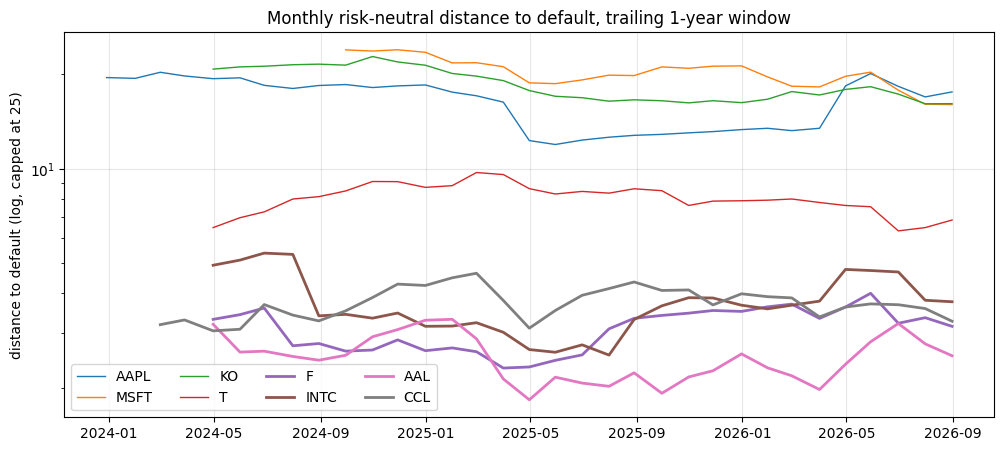

,2023-12-31,2024-12-31,2025-12-31,2026-12-31
AAPL,19.52,18.49,13.32,17.57
MSFT,NaN,23.50,21.27,16.01
KO,NaN,21.37,16.24,16.12
T,NaN,8.72,7.90,6.86
F,NaN,2.63,3.51,3.14
INTC,NaN,3.14,3.67,3.76
AAL,NaN,3.29,2.57,2.53
CCL,NaN,4.24,3.99,3.26


In [8]:
def dd_history(df, start="2023-01-31"):
    out = {}
    for d in pd.date_range(start, df.index[-1], freq="ME"):
        w = df.loc[:d].iloc[-DAYS:]
        if len(w) < DAYS or not w.pit.all():
            continue
        k = kmv_iterative(w.E.values, w.F.values, w.r.values)
        out[w.index[-1]] = distance_to_default(k["V"], w.F.iloc[-1], k["sigma_V"], w.r.iloc[-1])
    return pd.Series(out)


hist = pd.DataFrame({t: dd_history(df) for t, df in firms.items()})
fig, ax = plt.subplots(figsize=(12, 5))
for t in hist.columns:
    ax.plot(hist.index, hist[t].clip(upper=25), label=t, lw=2 if t in ("AAL", "CCL", "INTC", "F") else 1)
ax.set_yscale("log"); ax.set_ylabel("distance to default (log, capped at 25)")
ax.set_title("Monthly risk-neutral distance to default, trailing 1-year window")
ax.legend(ncol=4); plt.show()
hist.resample("YE").last().round(2).T

## 7. Leverage × volatility → default probability

PD is highly non-linear in both inputs. The same asset volatility that is harmless at 30% leverage is dangerous at 80%. This is the same leverage-and-nonlinearity effect as in Module 4, seen from the lender's side. The dots place the eight firms on the map.

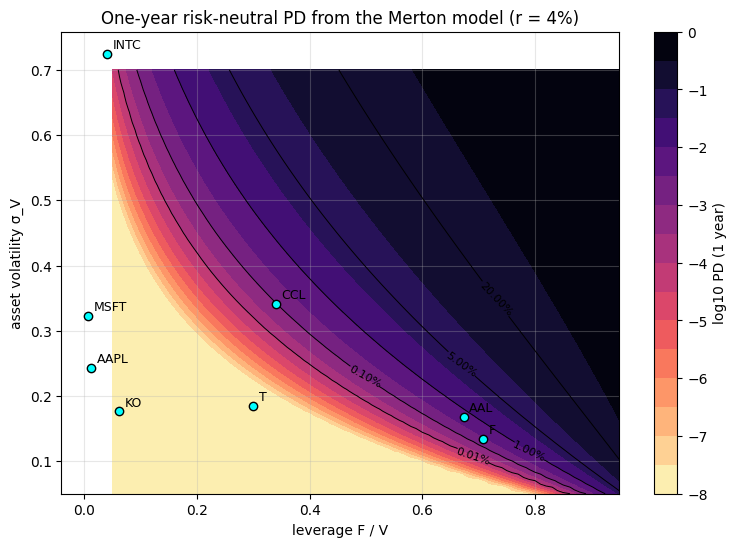

In [9]:
levs = np.linspace(0.05, 0.95, 91)
sigs = np.linspace(0.05, 0.70, 66)
L, S = np.meshgrid(levs, sigs)
PD = norm.cdf(-distance_to_default(1.0, L, S, 0.04))

fig, ax = plt.subplots(figsize=(9, 6))
cs = ax.contourf(L, S, np.log10(np.clip(PD, 1e-8, 1)), levels=np.arange(-8, 0.5, 0.5), cmap="magma_r")
lines = ax.contour(L, S, PD, levels=[1e-4, 1e-3, 1e-2, 0.05, 0.2], colors="k", linewidths=0.7)
ax.clabel(lines, fmt=lambda v: f"{v:.2%}", fontsize=8)
ax.scatter(xs["leverage F/V"], xs["σ_V"], c="cyan", edgecolor="k", zorder=3)
for t, row in xs.iterrows():
    ax.annotate(t, (row["leverage F/V"], row["σ_V"]), xytext=(4, 4), textcoords="offset points", fontsize=9)
fig.colorbar(cs, label="log10 PD (1 year)")
ax.set_xlabel("leverage F / V"); ax.set_ylabel("asset volatility σ_V")
ax.set_title("One-year risk-neutral PD from the Merton model (r = 4%)")
plt.show()

## 8. Takeaways

The numbers below come from the run with yfinance data up to Sep 2026.

- **The option view works as a measuring device.** On simulated firms, the iterative KMV estimator recovers asset volatility to within about 4% (close to the sampling-noise floor for one year of data) and ranks distance to default almost perfectly (Spearman 0.997). The two-equation shortcut is about 3× less accurate because it freezes equity volatility while leverage moves. The naive σ_V overstates asset volatility by about a third, yet it still ranks firms reasonably (0.97). That is why Bharath & Shumway found it forecasts almost as well.
- **The ranking makes sense.** AAL (leverage 0.67), Ford (0.71) and CCL are closest to default with DD ≈ 2.5–3, and AAPL, MSFT and KO are 15+ standard deviations away. INTC shows why volatility matters as much as leverage: debt is tiny relative to equity, but a 79% equity volatility pulls its DD down to about 4.
- **The levels are too optimistic: the credit spread puzzle.** The model gives AAL a 1-year PD of about 0.6% and a spread of about 3 bps. Its bonds actually trade at hundreds of bps over Treasuries. Pure-diffusion Merton cannot produce meaningful short-horizon spreads because default can't happen by a sudden jump, and it ignores liquidity and risk premia (Huang & Huang, 2012). Practitioners therefore map DD to empirical default frequencies (KMV's EDF) instead of reading $N(-DD)$ literally.
- **The balance-sheet input is the weakest link.** Ford's default point includes about $100bn of Ford Credit debt that is backed by loan receivables, not by the auto business. So "leverage 0.71" overstates the risk of the industrial firm. Banks and captive-finance firms need a different default point.
- **Relative changes are what matter.** The monthly DD history is most useful as an early-warning signal. A falling DD for one firm, relative to its own history and its peers, contains information that annual ratings update slowly.

**Extensions:** map DD to realized default rates, add jumps (Zhou, 2001) or a stochastic default barrier (Black-Cox) to fix short-term spreads, compare model spreads with market CDS/bond spreads, and use DD as a factor in the equity cross-section (Vassalou & Xing, 2004).